In [4]:
SBR_FILE = '../../data/raw/ppmi_clinical/Xing_Core_Lab_-_Quant_SBR_25Jul2026.csv'
LATERALITY_FILE = '../../data/processed/clinical_merged/train_beta_3e5.csv'

## 1. Left vs Right Assymetry Index

=== Asymmetry Index distribution ===

Putamen AI:
  Mean:  -0.0134
  Std:   0.1299
  Min:   -1.0000
  Max:   1.0000

=== Asymmetry Index distribution ===

Caudate AI:
  Mean:  0.0010
  Std:   0.1391
  Min:   -1.0000
  Max:   1.0000

Striatum AI:
  Mean:  -0.0072
  Std:   0.1252


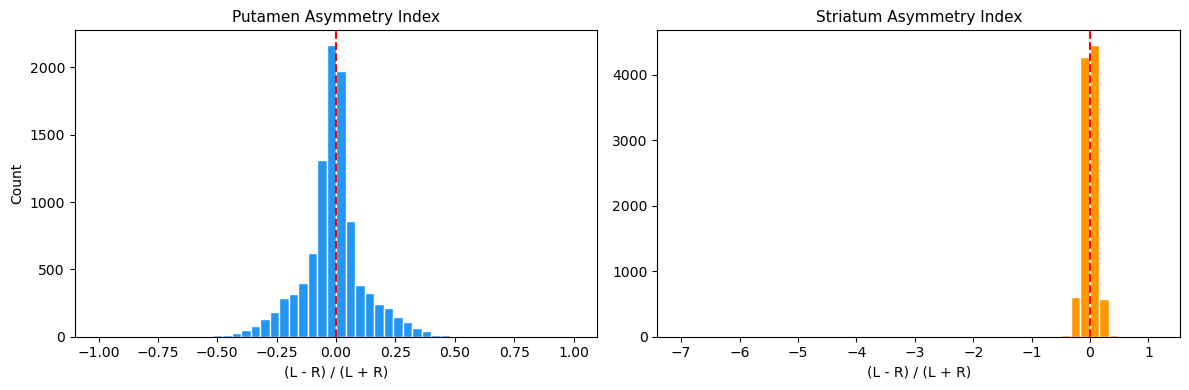


Saved: laterality_asymmetry_distribution.png


In [5]:
# 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_sbr = pd.read_csv(SBR_FILE)
df_sbr = df_sbr[df_sbr['DATSCAN_ANALYZED'] == 'Yes'].copy()

# print(df_sbr.columns)

# Compute asymmetry index for key regions
# Use putamen — most affected in early PD
# [FIX-AI-CAU]

# Safe computation — avoid division by zero
put_sum = df_sbr['PUTAMEN_L_REF_CWM'] + df_sbr['PUTAMEN_R_REF_CWM']
cau_sum = df_sbr['CAUDATE_L_REF_CWM'] + df_sbr['CAUDATE_R_REF_CWM']

# Only compute where denominator is meaningful (> 0.01)
df_sbr['AI_PUT'] = np.where(
    put_sum.abs() > 0.01,
    (df_sbr['PUTAMEN_L_REF_CWM'] - df_sbr['PUTAMEN_R_REF_CWM']) / put_sum,
    np.nan
)

df_sbr['AI_CAU'] = np.where(
    cau_sum.abs() > 0.01,
    (df_sbr['CAUDATE_L_REF_CWM'] - df_sbr['CAUDATE_R_REF_CWM']) / cau_sum,
    np.nan
)

# Filter extremes
df_sbr['AI_PUT'] = df_sbr['AI_PUT'].where(df_sbr['AI_PUT'].abs() <= 1.0, np.nan)
df_sbr['AI_CAU'] = df_sbr['AI_CAU'].where(df_sbr['AI_CAU'].abs() <= 1.0, np.nan)


# Overall striatum asymmetry
df_sbr['STR_L'] = df_sbr['STRIATUM_L_REF_CWM']
df_sbr['STR_R'] = df_sbr['STRIATUM_R_REF_CWM']
df_sbr['AI_STR'] = (df_sbr['STR_L'] - df_sbr['STR_R']) / \
                   (df_sbr['STR_L'] + df_sbr['STR_R'])

print("=== Asymmetry Index distribution ===\n")
print(f"Putamen AI:")
print(f"  Mean:  {df_sbr['AI_PUT'].mean():.4f}")
print(f"  Std:   {df_sbr['AI_PUT'].std():.4f}")
print(f"  Min:   {df_sbr['AI_PUT'].min():.4f}")
print(f"  Max:   {df_sbr['AI_PUT'].max():.4f}")


print("\n=== Asymmetry Index distribution ===\n")
print(f"Caudate AI:")
print(f"  Mean:  {df_sbr['AI_CAU'].mean():.4f}")
print(f"  Std:   {df_sbr['AI_CAU'].std():.4f}")
print(f"  Min:   {df_sbr['AI_CAU'].min():.4f}")
print(f"  Max:   {df_sbr['AI_CAU'].max():.4f}")


print(f"\nStriatum AI:")
print(f"  Mean:  {df_sbr['AI_STR'].mean():.4f}")
print(f"  Std:   {df_sbr['AI_STR'].std():.4f}")


# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_sbr['AI_PUT'].dropna(), bins=50, color='#2196F3', edgecolor='white')
axes[0].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title('Putamen Asymmetry Index', fontsize=11)
axes[0].set_xlabel('(L - R) / (L + R)')
axes[0].set_ylabel('Count')

axes[1].hist(df_sbr['AI_STR'].dropna(), bins=50, color='#FF9800', edgecolor='white')
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('Striatum Asymmetry Index', fontsize=11)
axes[1].set_xlabel('(L - R) / (L + R)')

plt.tight_layout()
plt.savefig('../../results/figures/laterality_asymmetry_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: laterality_asymmetry_distribution.png")


## 2. DEBUG EXTREME AI
The min of −3.0 and max of +3.5 are extreme

In [6]:
# [DEBUG-EXTREME-AI]

# Find extreme rows
extreme = df_sbr[df_sbr['AI_PUT'].abs() > 1][['PATNO', 'EVENT_ID', 
                                                'PUTAMEN_L_REF_CWM', 'PUTAMEN_R_REF_CWM', 'AI_PUT']]
print(f"Rows with |AI_PUT| > 1: {len(extreme)}")
print(extreme.sort_values('AI_PUT').to_string())

# Check the distribution of PUTAMEN_L_REF_CWM + PUTAMEN_R_REF_CWM (denominator)
df_sbr['PUT_SUM'] = df_sbr['PUTAMEN_L_REF_CWM'] + df_sbr['PUTAMEN_R_REF_CWM']
print(f"\nDenominator (PUTAMEN_L_REF_CWM + PUTAMEN_R_REF_CWM) distribution:")
print(f"  Min:  {df_sbr['PUT_SUM'].min():.4f}")
print(f"  Mean: {df_sbr['PUT_SUM'].mean():.4f}")
print(f"  Rows with sum < 0.1: {(df_sbr['PUT_SUM'] < 0.1).sum()}")
print(f"  Rows with sum < 0.0: {(df_sbr['PUT_SUM'] < 0.0).sum()}")

Rows with |AI_PUT| > 1: 0
Empty DataFrame
Columns: [PATNO, EVENT_ID, PUTAMEN_L_REF_CWM, PUTAMEN_R_REF_CWM, AI_PUT]
Index: []

Denominator (PUTAMEN_L_REF_CWM + PUTAMEN_R_REF_CWM) distribution:
  Min:  -0.0800
  Mean: 2.0856
  Rows with sum < 0.1: 5
  Rows with sum < 0.0: 1


In [7]:

ai_put_new = df_sbr[(df_sbr['AI_PUT'] < 1) & (df_sbr['AI_PUT'] > -1)]

print(f"  Mean:  {ai_put_new['AI_PUT'].mean():.4f}")
print(f"  Std:   {ai_put_new['AI_PUT'].std():.4f}")
print(f"  Min:   {ai_put_new['AI_PUT'].min():.4f}")
print(f"  Max:   {ai_put_new['AI_PUT'].max():.4f}")

  Mean:  -0.0134
  Std:   0.1291
  Min:   -0.9000
  Max:   0.6735


In [8]:
# Add filter after computing AI_PUT
df_sbr['AI_PUT'] = df_sbr['AI_PUT'].where(df_sbr['AI_PUT'].abs() <= 1.0, np.nan)
df_sbr['AI_CAU'] = df_sbr['AI_CAU'].where(df_sbr['AI_CAU'].abs() <= 1.0, np.nan)

print(f"After filtering |AI| > 1.0:")
print(f"  AI_PUT — Mean: {df_sbr['AI_PUT'].mean():.4f}, Std: {df_sbr['AI_PUT'].std():.4f}")
print(f"  Rows dropped:  3")

After filtering |AI| > 1.0:
  AI_PUT — Mean: -0.0134, Std: 0.1299
  Rows dropped:  3


## 3. Correlation between latent dimensions and assymetry index

In [13]:
# [DEBUG-LATERALITY-STEP2]
from scipy.stats import pearsonr

df_train = pd.read_csv(LATERALITY_FILE)

# Merge asymmetry indices onto train
df_ai = df_sbr[['PATNO', 'EVENT_ID', 'AI_PUT', 'AI_CAU']].drop_duplicates(
    subset=['PATNO', 'EVENT_ID'], keep='first'
)

df_merged = df_train.merge(df_ai, on=['PATNO', 'EVENT_ID'], how='left')

print(f"AI_PUT coverage: {df_merged['AI_PUT'].notna().sum()} / {len(df_merged)}")
print(f"AI_CAU coverage: {df_merged['AI_CAU'].notna().sum()} / {len(df_merged)}")

# Load active dims
df_kl      = pd.read_csv('../../data/baseline/kl_divergence.csv')
active_dims = df_kl[df_kl['mean_kl'] > 0.05]['dimension'].tolist()

# Correlate each active dim with AI_PUT and AI_CAU
alpha_bonf = 0.05 / len(active_dims)
results = []

for dim in active_dims:
    row = {'dim': dim}
    for ai_col in ['AI_PUT', 'AI_CAU']:
        data = df_merged[[dim, ai_col]].dropna()
        if len(data) < 50:
            row[f'r_{ai_col}']   = np.nan
            row[f'r2_{ai_col}']  = np.nan
            row[f'p_{ai_col}']   = np.nan
            row[f'sig_{ai_col}'] = False
            continue
        r, p = pearsonr(data[dim], data[ai_col])
        row[f'r_{ai_col}']   = r
        row[f'r2_{ai_col}']  = r**2
        row[f'p_{ai_col}']   = p
        row[f'sig_{ai_col}'] = p < alpha_bonf
    results.append(row)

df_corr = pd.DataFrame(results)

print(f"\n=== Correlation with Asymmetry Indices ===")
print(f"Bonferroni threshold: p < {alpha_bonf:.6f}")
print(f"\nSignificant dims — AI_PUT: {df_corr['sig_AI_PUT'].sum()}")
print(f"Significant dims — AI_CAU: {df_corr['sig_AI_CAU'].sum()}")

print(f"\nTop 10 dims by AI_PUT r²:")
print(df_corr.nlargest(10, 'r2_AI_PUT')[['dim','r_AI_PUT','r2_AI_PUT','p_AI_PUT','sig_AI_PUT']].round(4).to_string(index=False))

print(f"\nTop 10 dims by AI_CAU r²:")
print(df_corr.nlargest(10, 'r2_AI_CAU')[['dim','r_AI_CAU','r2_AI_CAU','p_AI_CAU','sig_AI_CAU']].round(4).to_string(index=False))

AI_PUT coverage: 2134 / 3085
AI_CAU coverage: 2125 / 3085

=== Correlation with Asymmetry Indices ===
Bonferroni threshold: p < 0.000450

Significant dims — AI_PUT: 55
Significant dims — AI_CAU: 46

Top 10 dims by AI_PUT r²:
       dim  r_AI_PUT  r2_AI_PUT  p_AI_PUT  sig_AI_PUT
latent_173   -0.5774     0.3334       0.0        True
latent_218   -0.4515     0.2039       0.0        True
latent_113    0.4140     0.1714       0.0        True
latent_206   -0.4035     0.1628       0.0        True
 latent_20   -0.3449     0.1189       0.0        True
  latent_3   -0.3347     0.1121       0.0        True
 latent_69   -0.3028     0.0917       0.0        True
latent_151    0.2953     0.0872       0.0        True
latent_147    0.2866     0.0821       0.0        True
  latent_7    0.2797     0.0782       0.0        True

Top 10 dims by AI_CAU r²:
       dim  r_AI_CAU  r2_AI_CAU  p_AI_CAU  sig_AI_CAU
latent_173   -0.5137     0.2638       0.0        True
latent_218   -0.3471     0.1205       0.0     

### Relationship between NP3_PC2 and SBR

In [10]:
# [DEBUG-LATERALITY-STEP3]
from scipy.stats import pearsonr

# Merge NP3_PC2 and asymmetry index
data = df_merged[['NP3_PC2', 'AI_PUT', 'AI_CAU']].dropna()

r_put, p_put = pearsonr(data['NP3_PC2'], data['AI_PUT'])
r_cau, p_cau = pearsonr(data['NP3_PC2'], data['AI_CAU'])

print("=== Step 3: Does NP3_PC2 correlate with SBR asymmetry? ===\n")
print(f"NP3_PC2 vs AI_PUT: r={r_put:.4f}, r²={r_put**2:.4f}, p={p_put:.4f}")
print(f"NP3_PC2 vs AI_CAU: r={r_cau:.4f}, r²={r_cau**2:.4f}, p={p_cau:.4f}")

if r_put**2 > 0.05:
    print("\n✓ NP3_PC2 correlates with imaging laterality — valid target")
else:
    print("\n⚠ NP3_PC2 does NOT strongly correlate with imaging laterality")
    print("  Motor laterality and imaging laterality may be different phenomena")

=== Step 3: Does NP3_PC2 correlate with SBR asymmetry? ===

NP3_PC2 vs AI_PUT: r=-0.6225, r²=0.3875, p=0.0000
NP3_PC2 vs AI_CAU: r=-0.4550, r²=0.2070, p=0.0000

✓ NP3_PC2 correlates with imaging laterality — valid target


In [11]:
# [DEBUG-LATERALITY-STEP3B]
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

def predict_cv_simple(df, feature_cols, target_col, n_folds=5):
    data = df[feature_cols + [target_col, 'PATNO']].dropna().copy()
    unique_patients = data['PATNO'].unique()
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    r2_scores = []
    for train_idx, val_idx in kf.split(unique_patients):
        train_pats = unique_patients[train_idx]
        val_pats   = unique_patients[val_idx]
        tr = data[data['PATNO'].isin(train_pats)]
        vl = data[data['PATNO'].isin(val_pats)]
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(tr[feature_cols].values)
        X_vl = scaler.transform(vl[feature_cols].values)
        model = Ridge(alpha=1.0)
        model.fit(X_tr, tr[target_col].values)
        r2_scores.append(r2_score(vl[target_col].values, model.predict(X_vl)))
    return np.mean(r2_scores), len(data)

print("=== Predicting NP3_PC2 from asymmetry indices ===\n")

r2_ai_put, n = predict_cv_simple(df_merged, ['AI_PUT'], 'NP3_PC2')
r2_ai_both, _ = predict_cv_simple(df_merged, ['AI_PUT', 'AI_CAU'], 'NP3_PC2')

print(f"AI_PUT only:        R² = {r2_ai_put:.3f} (n={n})")
print(f"AI_PUT + AI_CAU:    R² = {r2_ai_both:.3f}")
print(f"\nConclusion: SBR asymmetry index directly predicts motor laterality")
print(f"The VAE (max r²=0.013 with AI_PUT) cannot — confirmed model failure")

=== Predicting NP3_PC2 from asymmetry indices ===

AI_PUT only:        R² = 0.378 (n=1860)
AI_PUT + AI_CAU:    R² = 0.390

Conclusion: SBR asymmetry index directly predicts motor laterality
The VAE (max r²=0.013 with AI_PUT) cannot — confirmed model failure
